<a href="https://colab.research.google.com/github/harshita042/PRML-CSL2050/blob/main/lab_25_feb_pca_lda_eigenfaces.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Principal Component Analysis (PCA) and Linear Discriminant Analysis (LDA)

## 1. Setup and Imports

In [ ]:
# Standard libraries
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn imports
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Set random seed for reproducibility
np.random.seed(42)

# Plot settings
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## 2. Load and Explore the Dataset

We'll use the **Olivetti Faces** dataset, which contains 400 grayscale face images (64×64 pixels) of 40 different people (10 images per person).

In [ ]:
# Load the Olivetti Faces dataset
faces = fetch_olivetti_faces(shuffle=True, random_state=42)
X = faces.data  # Feature matrix (400, 4096) - each image is 64x64 = 4096 pixels
y = faces.target  # Labels (400,) - person ID (0-39)

n_samples, n_features = X.shape
n_classes = len(np.unique(y))
h, w = faces.images.shape[1:]

print(f"Dataset Information:")
print(f"  Number of samples: {n_samples}")
print(f"  Number of features (pixels): {n_features}")
print(f"  Number of classes (people): {n_classes}")
print(f"  Image dimensions: {h} × {w}")
print(f"  Samples per class: ~{n_samples // n_classes}")

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data
Dataset Information:
  Number of samples: 400
  Number of features (pixels): 4096
  Number of classes (people): 40
  Image dimensions: 64 × 64
  Samples per class: ~10


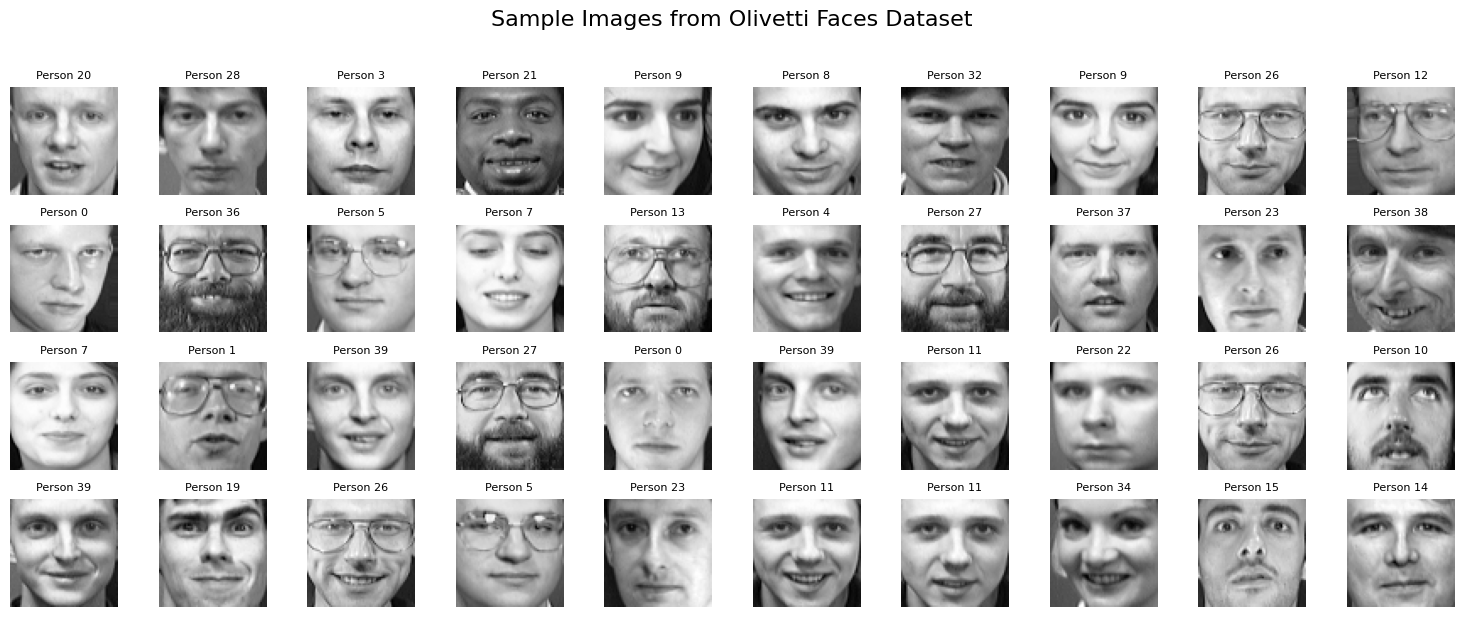

In [ ]:
# Visualize sample faces
fig, axes = plt.subplots(4, 10, figsize=(15, 6))
fig.suptitle('Sample Images from Olivetti Faces Dataset', fontsize=16, y=1.02)

for i, ax in enumerate(axes.flat):
    ax.imshow(faces.images[i], cmap='gray')
    ax.set_title(f'Person {y[i]}', fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 3. Principal Component Analysis (PCA)

### What is PCA?

**PCA** is an **unsupervised** dimensionality reduction technique that:
- Identifies directions (principal components) of maximum variance in the data
- Projects data onto these components to reduce dimensionality
- Preserves as much variance as possible

### Key Characteristics:
- **Unsupervised**: Doesn't use class labels
- **Variance-based**: Maximizes variance in projected space
- **Orthogonal components**: Principal components are perpendicular to each other
- **Eigenfaces**: In face recognition, principal components are called "eigenfaces"

### 3.1 Apply PCA and Visualize Eigenfaces

In [ ]:
# Apply PCA with enough components to explain most variance
n_components_pca = 150
pca = PCA(n_components=n_components_pca, whiten=True, random_state=42)
X_pca = pca.fit_transform(X)

print(f"PCA applied with {n_components_pca} components")
print(f"Original shape: {X.shape}")
print(f"Reduced shape: {X_pca.shape}")
print(f"Variance explained by {n_components_pca} components: {pca.explained_variance_ratio_.sum():.2%}")

PCA applied with 150 components
Original shape: (400, 4096)
Reduced shape: (400, 150)
Variance explained by 150 components: 96.29%


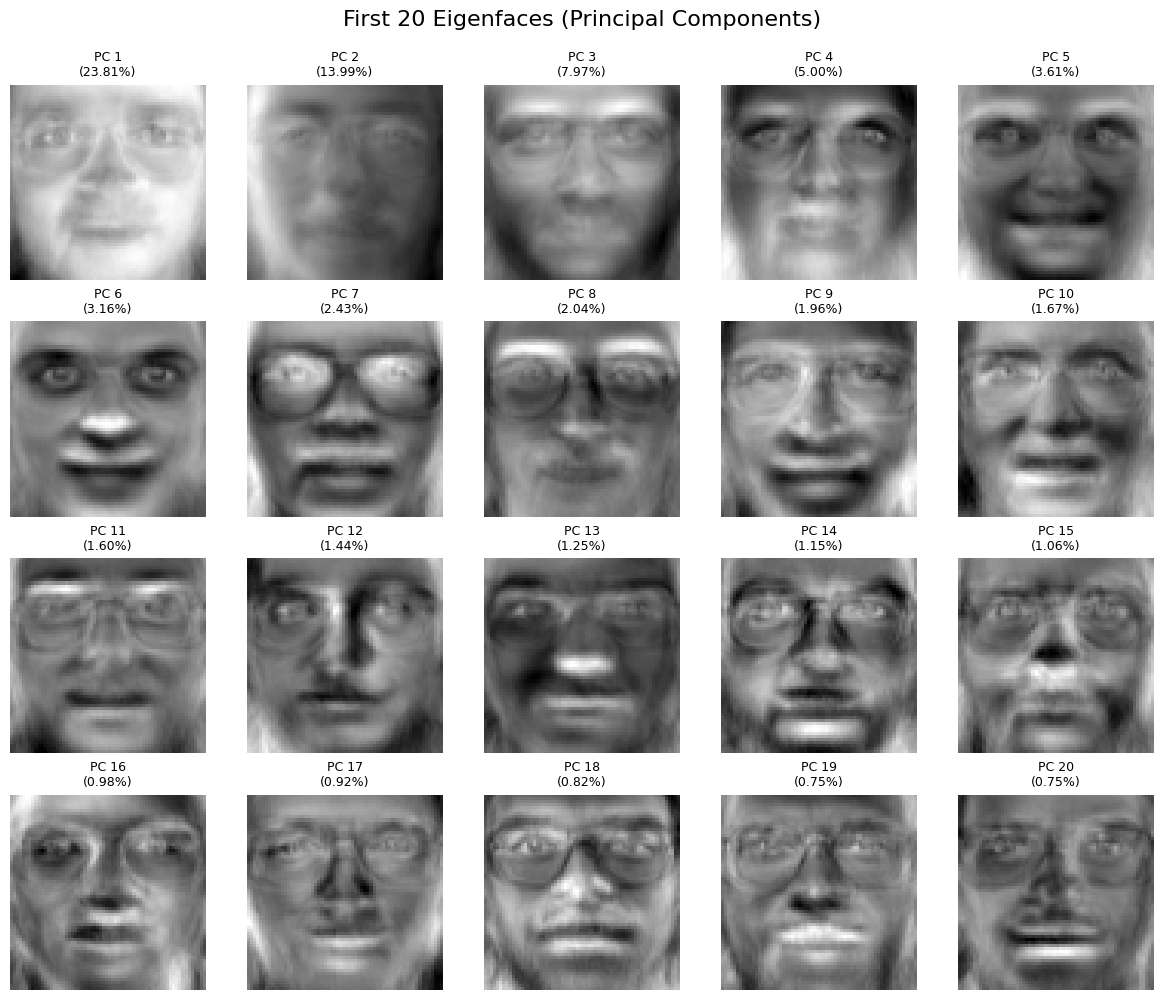


Eigenfaces represent the principal components of variation in the face dataset.
Each eigenface captures a different aspect of facial variation (lighting, expression, pose, etc.)


In [ ]:
# Visualize the first 20 eigenfaces
fig, axes = plt.subplots(4, 5, figsize=(12, 10))
fig.suptitle('First 20 Eigenfaces (Principal Components)', fontsize=16, y=0.995)

for i, ax in enumerate(axes.flat):
    # Reshape component to image shape
    eigenface = pca.components_[i].reshape(h, w)

    ax.imshow(eigenface, cmap='gray')
    ax.set_title(f'PC {i+1}\n({pca.explained_variance_ratio_[i]:.2%})', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

print("\nEigenfaces represent the principal components of variation in the face dataset.")
print("Each eigenface captures a different aspect of facial variation (lighting, expression, pose, etc.)")

### 3.2 Component Selection Methods

Choosing the right number of components is crucial for balancing:
- **Information retention** (more components = more information)
- **Computational efficiency** (fewer components = faster)
- **Avoiding overfitting** (too many components may capture noise)

We'll explore three methods:
1. **Cumulative Explained Variance Threshold**
2. **Elbow Method**
3. **Cross-Validation Performance**

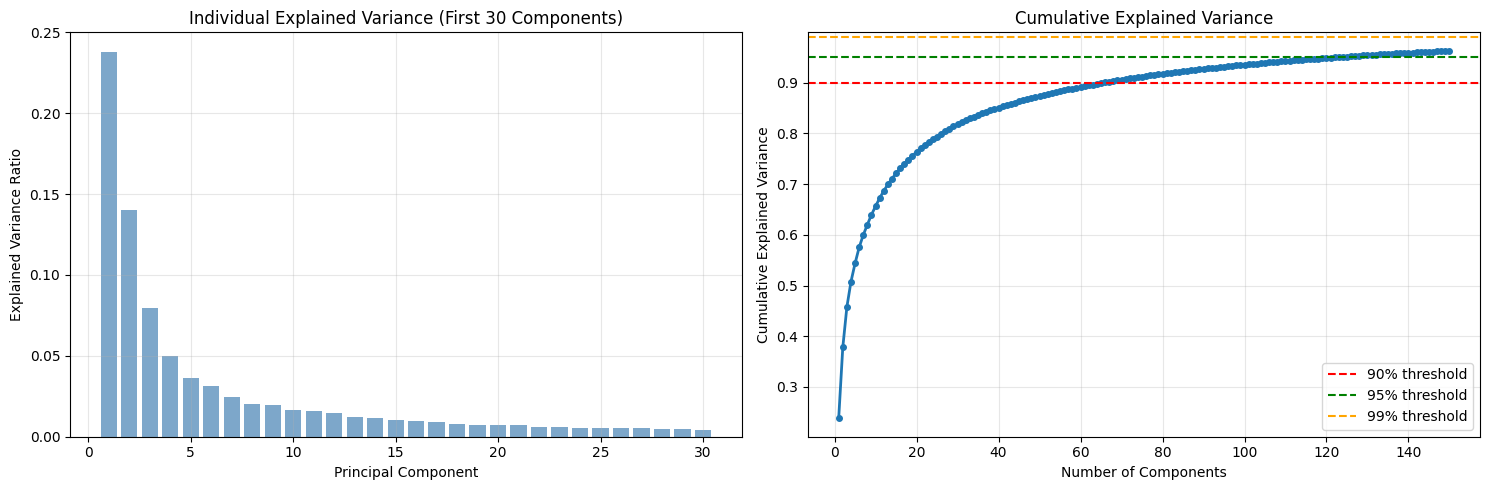

Components needed for 90% variance: 66
Components needed for 95% variance: 123
Components needed for 99% variance: 1


In [ ]:
# Method 1: Cumulative Explained Variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Individual variance
axes[0].bar(range(1, 31), pca.explained_variance_ratio_[:30], alpha=0.7, color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Individual Explained Variance (First 30 Components)')
axes[0].grid(alpha=0.3)

# Cumulative variance
axes[1].plot(range(1, n_components_pca + 1), cumulative_variance, 'o-', linewidth=2, markersize=4)
axes[1].axhline(y=0.90, color='r', linestyle='--', label='90% threshold')
axes[1].axhline(y=0.95, color='g', linestyle='--', label='95% threshold')
axes[1].axhline(y=0.99, color='orange', linestyle='--', label='99% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Find number of components for different thresholds
for threshold in [0.90, 0.95, 0.99]:
    n_comp = np.argmax(cumulative_variance >= threshold) + 1
    print(f"Components needed for {threshold:.0%} variance: {n_comp}")

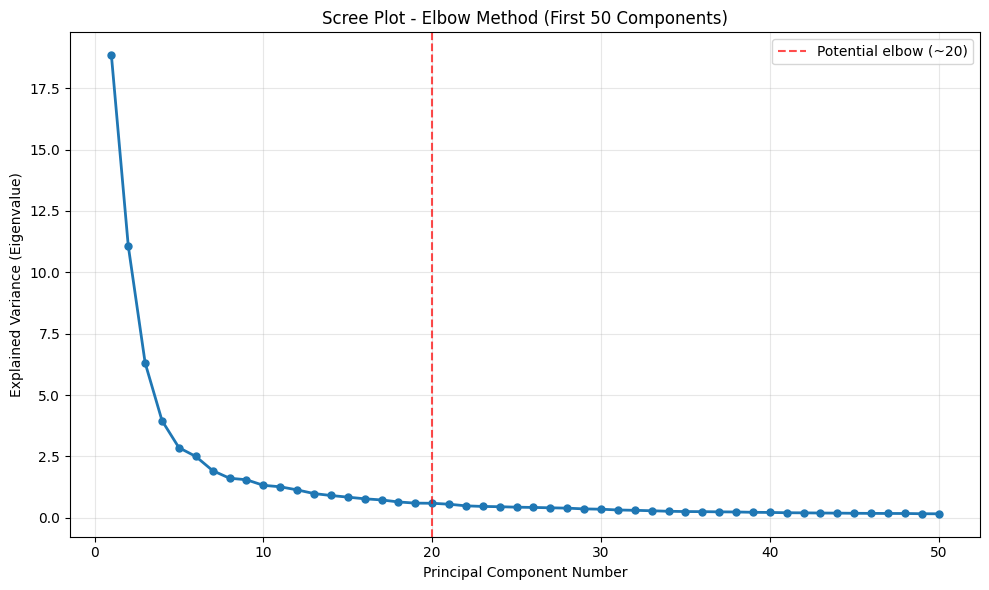


Elbow Method: Look for the point where the curve starts to flatten.
This suggests that additional components contribute less new information.


In [ ]:
# Method 2: Elbow Method
# Look for the "elbow" where adding more components provides diminishing returns

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, 51), pca.explained_variance_[:50], 'o-', linewidth=2, markersize=5)
ax.set_xlabel('Principal Component Number')
ax.set_ylabel('Explained Variance (Eigenvalue)')
ax.set_title('Scree Plot - Elbow Method (First 50 Components)')
ax.grid(alpha=0.3)
ax.axvline(x=20, color='red', linestyle='--', alpha=0.7, label='Potential elbow (~20)')
ax.legend()
plt.tight_layout()
plt.show()

print("\nElbow Method: Look for the point where the curve starts to flatten.")
print("This suggests that additional components contribute less new information.")

Testing classification accuracy with different numbers of PCA components...

n_components=  5: Train=0.367, Test=0.210
n_components= 10: Train=0.670, Test=0.550
n_components= 20: Train=0.967, Test=0.890
n_components= 30: Train=0.990, Test=0.910
n_components= 50: Train=1.000, Test=0.950
n_components= 75: Train=1.000, Test=0.980
n_components=100: Train=1.000, Test=0.980
n_components=150: Train=1.000, Test=0.970


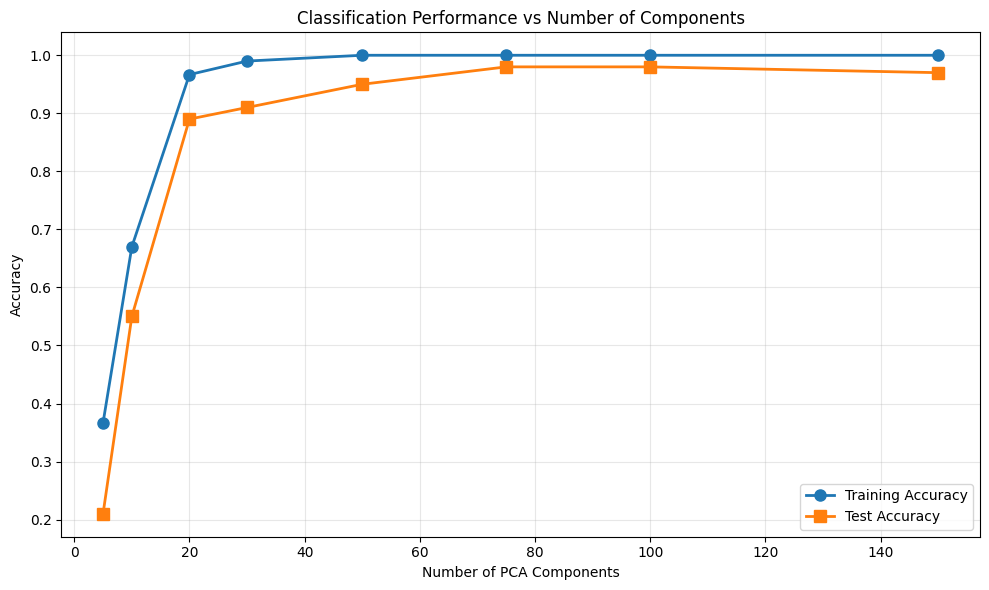


Best test accuracy (0.980) achieved with 75 components


In [ ]:
# Method 3: Cross-Validation Performance
# Test different numbers of components using a classifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

component_range = [5, 10, 20, 30, 50, 75, 100, 150]
train_scores = []
test_scores = []

print("Testing classification accuracy with different numbers of PCA components...\n")

for n_comp in component_range:
    # Apply PCA
    pca_temp = PCA(n_components=n_comp, whiten=True, random_state=42)
    X_train_pca = pca_temp.fit_transform(X_train)
    X_test_pca = pca_temp.transform(X_test)

    # Train classifier
    clf = SVC(kernel='rbf', C=10, gamma=0.001, random_state=42)
    clf.fit(X_train_pca, y_train)

    # Evaluate
    train_acc = clf.score(X_train_pca, y_train)
    test_acc = clf.score(X_test_pca, y_test)

    train_scores.append(train_acc)
    test_scores.append(test_acc)

    print(f"n_components={n_comp:3d}: Train={train_acc:.3f}, Test={test_acc:.3f}")

# Plot results
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(component_range, train_scores, 'o-', label='Training Accuracy', linewidth=2, markersize=8)
ax.plot(component_range, test_scores, 's-', label='Test Accuracy', linewidth=2, markersize=8)
ax.set_xlabel('Number of PCA Components')
ax.set_ylabel('Accuracy')
ax.set_title('Classification Performance vs Number of Components')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_n = component_range[np.argmax(test_scores)]
print(f"\nBest test accuracy ({max(test_scores):.3f}) achieved with {best_n} components")

### 3.3 Face Reconstruction with PCA

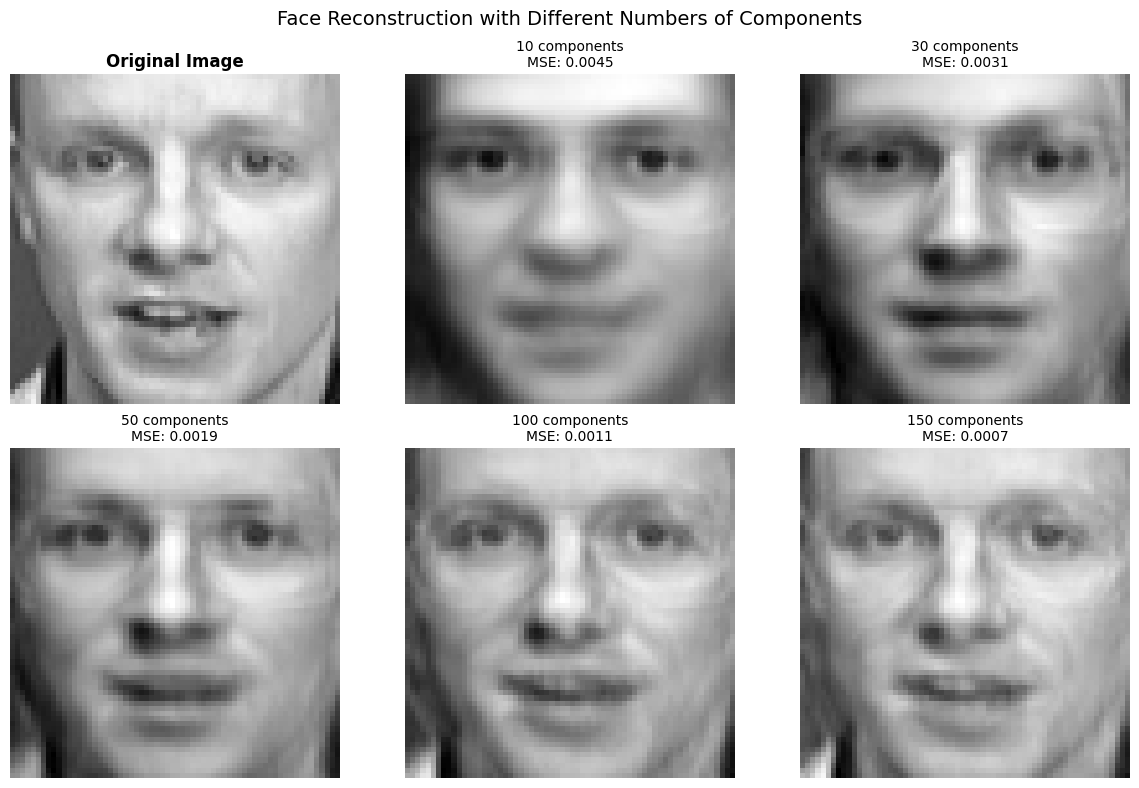

In [ ]:
# Demonstrate reconstruction with different numbers of components
sample_idx = 0
sample_face = X[sample_idx:sample_idx+1]

n_comp_list = [10, 30, 50, 100, 150]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

# Original
axes[0].imshow(sample_face.reshape(h, w), cmap='gray')
axes[0].set_title('Original Image', fontweight='bold')
axes[0].axis('off')

# Reconstructions
for idx, n_comp in enumerate(n_comp_list, 1):
    pca_temp = PCA(n_components=n_comp, whiten=True, random_state=42)
    pca_temp.fit(X)

    # Transform and inverse transform
    transformed = pca_temp.transform(sample_face)
    reconstructed = pca_temp.inverse_transform(transformed)

    # Calculate reconstruction error
    mse = np.mean((sample_face - reconstructed) ** 2)

    axes[idx].imshow(reconstructed.reshape(h, w), cmap='gray')
    axes[idx].set_title(f'{n_comp} components\nMSE: {mse:.4f}', fontsize=10)
    axes[idx].axis('off')

# As we increase the number of components, reconstruction quality improves.
plt.suptitle('Face Reconstruction with Different Numbers of Components', fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

## 4. Linear Discriminant Analysis (LDA)

### What is LDA?

**LDA** is a **supervised** dimensionality reduction technique that:
- Maximizes class separability (between-class variance)
- Minimizes within-class variance
- Uses class labels to find discriminative features

### Key Characteristics:
- **Supervised**: Uses class labels
- **Classification-focused**: Optimizes for class separation
- **Limited components**: Maximum of (n_classes - 1) components
- **Better for classification**: When labels are available and classification is the goal

In [ ]:
# Apply LDA
# LDA can have at most (n_classes - 1) components
n_components_lda = min(n_classes - 1, n_features)

print(f"Maximum LDA components possible: {n_components_lda} (n_classes - 1 = {n_classes} - 1)")

lda = LDA(n_components=n_components_lda)
X_lda = lda.fit_transform(X, y)

print(f"\nLDA applied with {n_components_lda} components")
print(f"Original shape: {X.shape}")
print(f"Reduced shape: {X_lda.shape}")
print(f"\nExplained variance ratio by first 10 components:")
for i in range(min(10, len(lda.explained_variance_ratio_))):
    print(f"  LD{i+1}: {lda.explained_variance_ratio_[i]:.4f}")

Maximum LDA components possible: 39 (n_classes - 1 = 40 - 1)

LDA applied with 39 components
Original shape: (400, 4096)
Reduced shape: (400, 39)

Explained variance ratio by first 10 components:
  LD1: 0.1453
  LD2: 0.1252
  LD3: 0.0796
  LD4: 0.0688
  LD5: 0.0532
  LD6: 0.0494
  LD7: 0.0447
  LD8: 0.0432
  LD9: 0.0371
  LD10: 0.0305


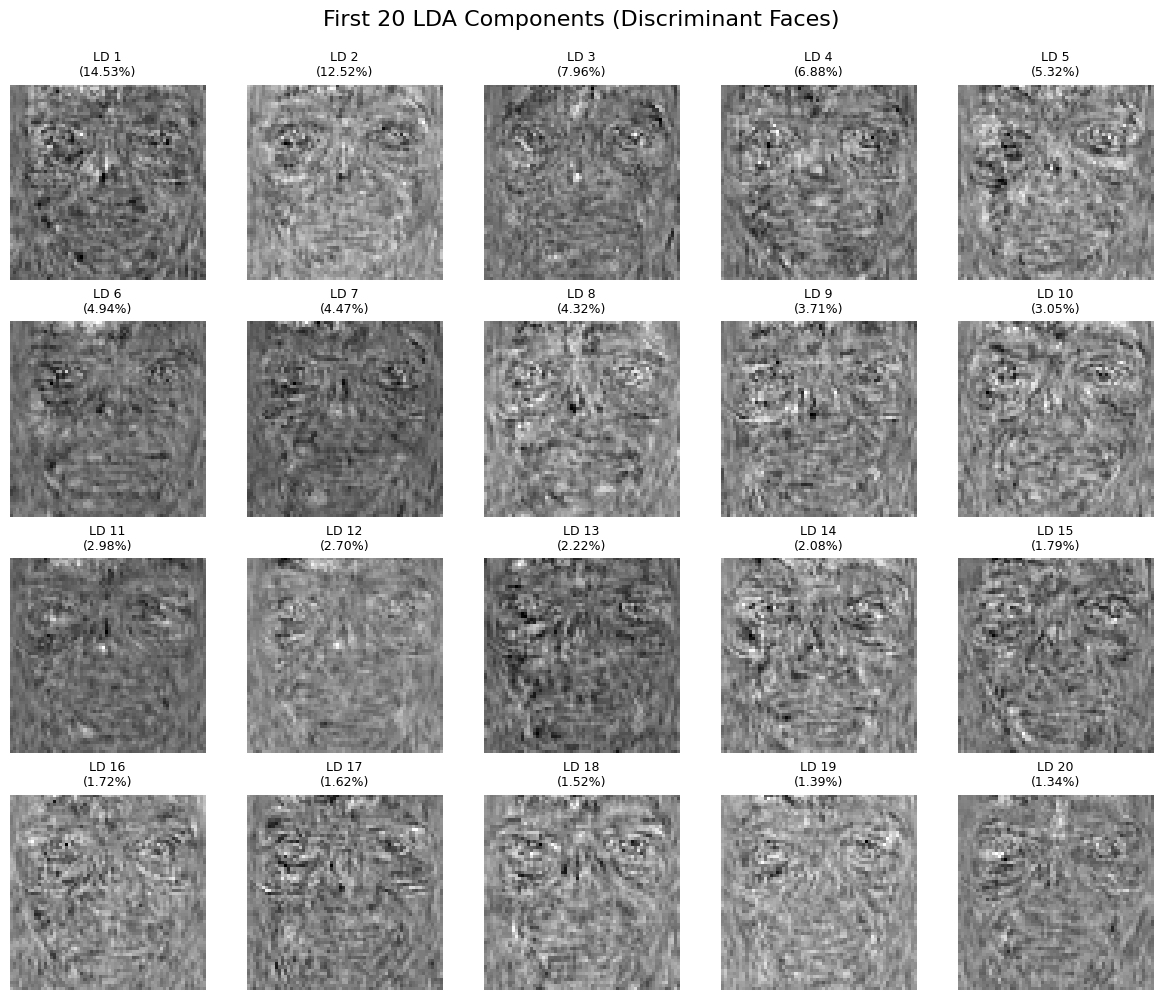


LDA components (discriminant faces) emphasize features that separate classes.
Unlike eigenfaces, these are optimized for classification, not variance.


In [ ]:
# Visualize LDA components (discriminant faces)
fig, axes = plt.subplots(4, 5, figsize=(12, 10))
fig.suptitle('First 20 LDA Components (Discriminant Faces)', fontsize=16, y=0.995)

for i, ax in enumerate(axes.flat):
    if i < n_components_lda:
        # Reshape component to image shape
        discriminant_face = lda.scalings_[:, i].reshape(h, w)

        ax.imshow(discriminant_face, cmap='gray')
        ax.set_title(f'LD {i+1}\n({lda.explained_variance_ratio_[i]:.2%})', fontsize=9)
    else:
        ax.text(0.5, 0.5, 'N/A', ha='center', va='center', fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

print("\nLDA components (discriminant faces) emphasize features that separate classes.")
print("Unlike eigenfaces, these are optimized for classification, not variance.")

Testing classification accuracy with different numbers of LDA components...

n_components=  5: Train=0.960, Test=0.850
n_components= 10: Train=1.000, Test=0.980
n_components= 15: Train=1.000, Test=0.950
n_components= 20: Train=1.000, Test=0.970
n_components= 25: Train=1.000, Test=0.960
n_components= 30: Train=1.000, Test=0.970
n_components= 35: Train=1.000, Test=0.970
n_components= 39: Train=1.000, Test=0.970


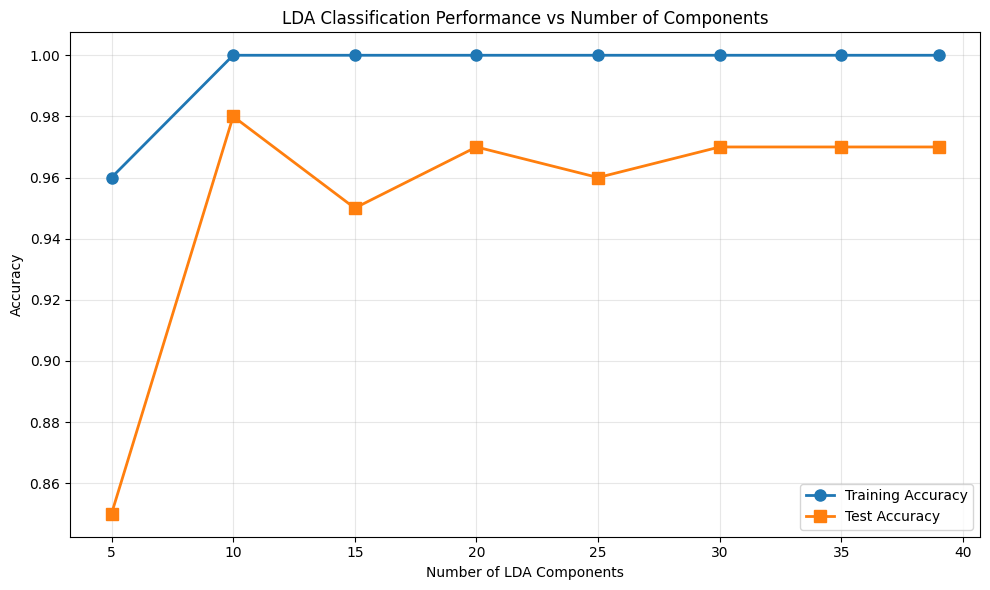


Best test accuracy (0.980) achieved with 10 components


In [ ]:
# Compare LDA performance with different numbers of components
component_range_lda = [5, 10, 15, 20, 25, 30, 35, 39]
train_scores_lda = []
test_scores_lda = []

print("Testing classification accuracy with different numbers of LDA components...\n")

for n_comp in component_range_lda:
    # Apply LDA
    lda_temp = LDA(n_components=n_comp)
    X_train_lda = lda_temp.fit_transform(X_train, y_train)
    X_test_lda = lda_temp.transform(X_test)

    # Train classifier
    clf = SVC(kernel='rbf', C=10, gamma=0.001, random_state=42)
    clf.fit(X_train_lda, y_train)

    # Evaluate
    train_acc = clf.score(X_train_lda, y_train)
    test_acc = clf.score(X_test_lda, y_test)

    train_scores_lda.append(train_acc)
    test_scores_lda.append(test_acc)

    print(f"n_components={n_comp:3d}: Train={train_acc:.3f}, Test={test_acc:.3f}")

# Plot results
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(component_range_lda, train_scores_lda, 'o-', label='Training Accuracy', linewidth=2, markersize=8)
ax.plot(component_range_lda, test_scores_lda, 's-', label='Test Accuracy', linewidth=2, markersize=8)
ax.set_xlabel('Number of LDA Components')
ax.set_ylabel('Accuracy')
ax.set_title('LDA Classification Performance vs Number of Components')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_n_lda = component_range_lda[np.argmax(test_scores_lda)]
print(f"\nBest test accuracy ({max(test_scores_lda):.3f}) achieved with {best_n_lda} components")

## 5. Comparative Visualizations

Let's visualize how PCA and LDA project the data differently.

### 5.1 2D Projections

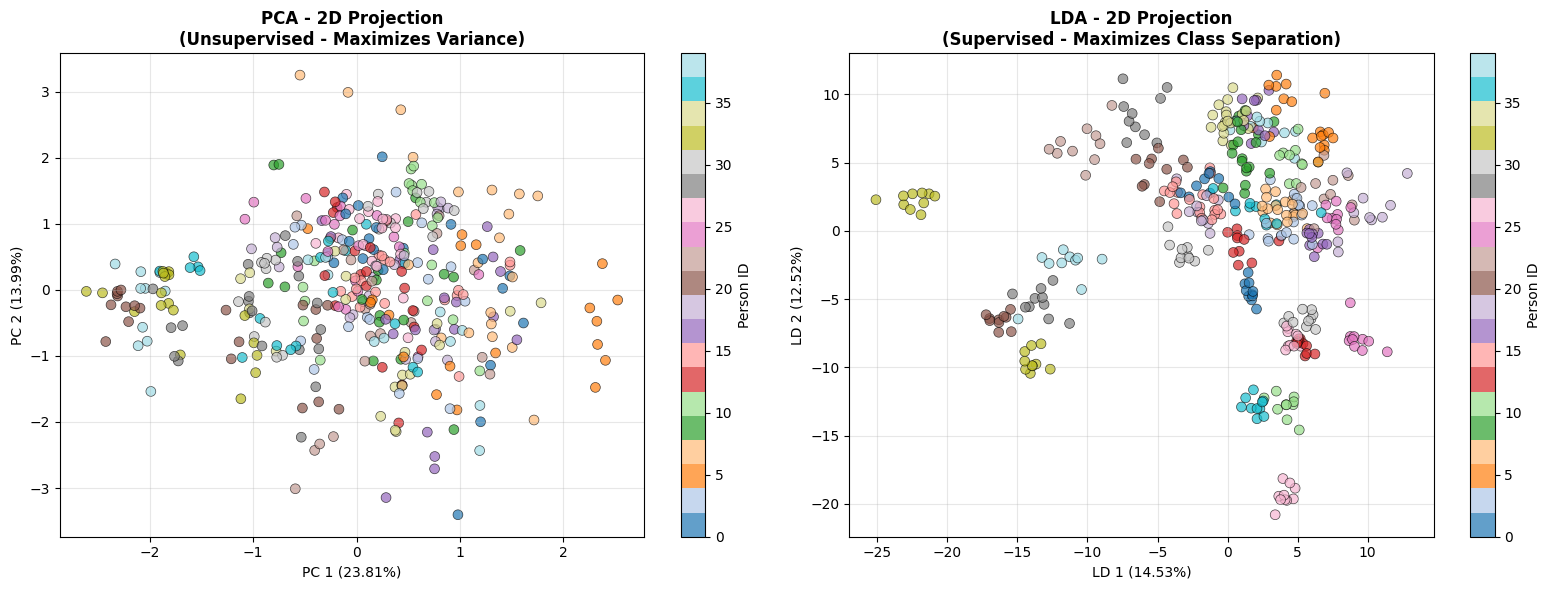


Observations:
  - PCA: Points are spread based on variance, classes may overlap
  - LDA: Better class separation, points of same class cluster together


In [ ]:
# Apply PCA and LDA with 2 components for visualization
pca_2d = PCA(n_components=2, whiten=True, random_state=42)
X_pca_2d = pca_2d.fit_transform(X)

lda_2d = LDA(n_components=2)
X_lda_2d = lda_2d.fit_transform(X, y)

# Create comparison plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA 2D
scatter1 = axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y, cmap='tab20',
                           alpha=0.7, s=50, edgecolors='black', linewidth=0.5)
axes[0].set_xlabel(f'PC 1 ({pca_2d.explained_variance_ratio_[0]:.2%})')
axes[0].set_ylabel(f'PC 2 ({pca_2d.explained_variance_ratio_[1]:.2%})')
axes[0].set_title('PCA - 2D Projection\n(Unsupervised - Maximizes Variance)', fontweight='bold')
axes[0].grid(alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Person ID')

# LDA 2D
scatter2 = axes[1].scatter(X_lda_2d[:, 0], X_lda_2d[:, 1], c=y, cmap='tab20',
                           alpha=0.7, s=50, edgecolors='black', linewidth=0.5)
axes[1].set_xlabel(f'LD 1 ({lda_2d.explained_variance_ratio_[0]:.2%})')
axes[1].set_ylabel(f'LD 2 ({lda_2d.explained_variance_ratio_[1]:.2%})')
axes[1].set_title('LDA - 2D Projection\n(Supervised - Maximizes Class Separation)', fontweight='bold')
axes[1].grid(alpha=0.3)
plt.colorbar(scatter2, ax=axes[1], label='Person ID')

plt.tight_layout()
plt.show()

print("\nObservations:")
print("  - PCA: Points are spread based on variance, classes may overlap")
print("  - LDA: Better class separation, points of same class cluster together")

### 5.2 3D Projections

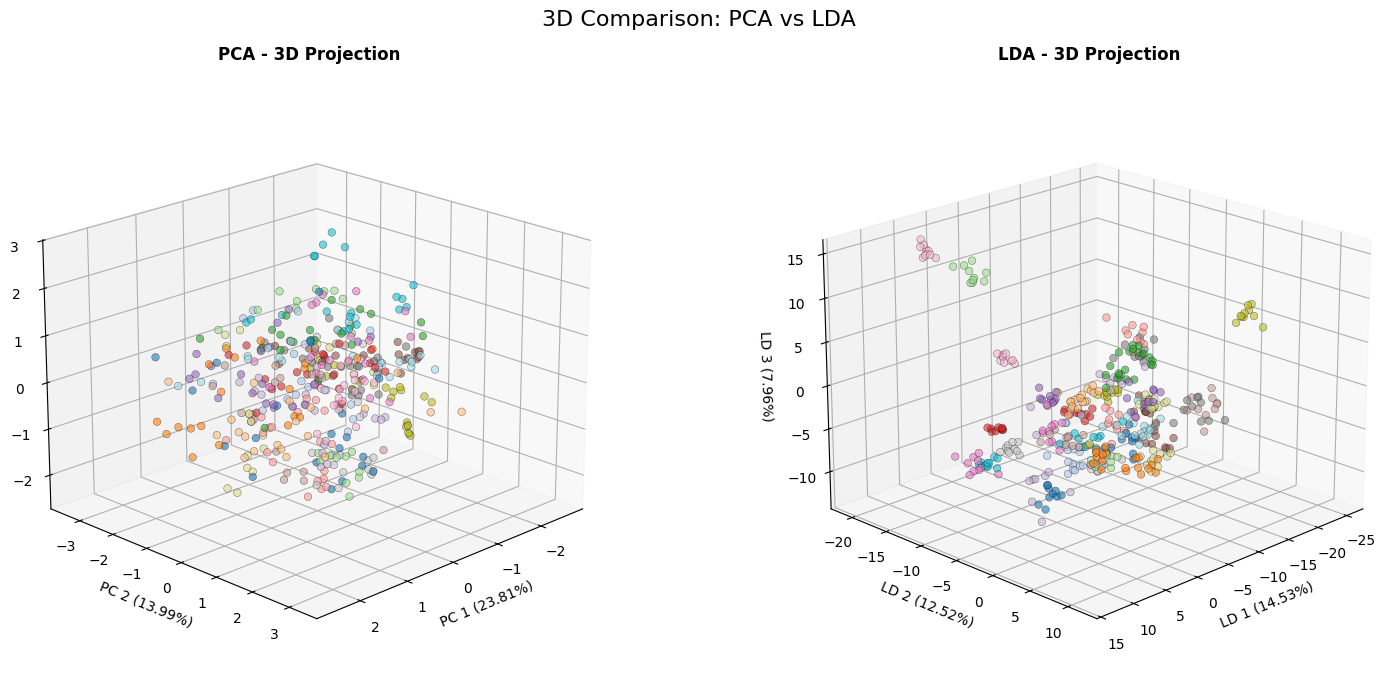


3D visualization shows that LDA provides better class clustering than PCA.


In [ ]:
# Apply PCA and LDA with 3 components for 3D visualization
pca_3d = PCA(n_components=3, whiten=True, random_state=42)
X_pca_3d = pca_3d.fit_transform(X)

lda_3d = LDA(n_components=3)
X_lda_3d = lda_3d.fit_transform(X, y)

# Create 3D comparison plot
fig = plt.figure(figsize=(16, 7))

# PCA 3D
ax1 = fig.add_subplot(121, projection='3d')
scatter1 = ax1.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2],
                       c=y, cmap='tab20', alpha=0.6, s=30, edgecolors='black', linewidth=0.3)
ax1.set_xlabel(f'PC 1 ({pca_3d.explained_variance_ratio_[0]:.2%})')
ax1.set_ylabel(f'PC 2 ({pca_3d.explained_variance_ratio_[1]:.2%})')
ax1.set_zlabel(f'PC 3 ({pca_3d.explained_variance_ratio_[2]:.2%})')
ax1.set_title('PCA - 3D Projection', fontweight='bold', pad=20)
ax1.view_init(elev=20, azim=45)

# LDA 3D
ax2 = fig.add_subplot(122, projection='3d')
scatter2 = ax2.scatter(X_lda_3d[:, 0], X_lda_3d[:, 1], X_lda_3d[:, 2],
                       c=y, cmap='tab20', alpha=0.6, s=30, edgecolors='black', linewidth=0.3)
ax2.set_xlabel(f'LD 1 ({lda_3d.explained_variance_ratio_[0]:.2%})')
ax2.set_ylabel(f'LD 2 ({lda_3d.explained_variance_ratio_[1]:.2%})')
ax2.set_zlabel(f'LD 3 ({lda_3d.explained_variance_ratio_[2]:.2%})')
ax2.set_title('LDA - 3D Projection', fontweight='bold', pad=20)
ax2.view_init(elev=20, azim=45)

plt.suptitle('3D Comparison: PCA vs LDA', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

print("\n3D visualization shows that LDA provides better class clustering than PCA.")

### 5.3 t-SNE Visualization

**t-SNE** (t-Distributed Stochastic Neighbor Embedding) is a non-linear dimensionality reduction technique excellent for visualization.
We'll compare t-SNE applied to:
1. Original high-dimensional data
2. PCA-reduced data
3. LDA-reduced data

In [ ]:
# Apply t-SNE to different representations
print("Computing t-SNE embeddings (this may take a minute)...\n")

# t-SNE on original data (using PCA first for speed)
pca_50 = PCA(n_components=50, random_state=42)
X_pca_50 = pca_50.fit_transform(X)
tsne_original = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne_original = tsne_original.fit_transform(X_pca_50)
print("✓ t-SNE on PCA-50 completed")

# t-SNE on PCA-reduced data
tsne_pca = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne_pca = tsne_pca.fit_transform(X_pca_2d)
print("✓ t-SNE on PCA-2 completed")

# t-SNE on LDA-reduced data
tsne_lda = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne_lda = tsne_lda.fit_transform(X_lda_2d)
print("✓ t-SNE on LDA-2 completed\n")

Computing t-SNE embeddings (this may take a minute)...

✓ t-SNE on PCA-50 completed
✓ t-SNE on PCA-2 completed
✓ t-SNE on LDA-2 completed



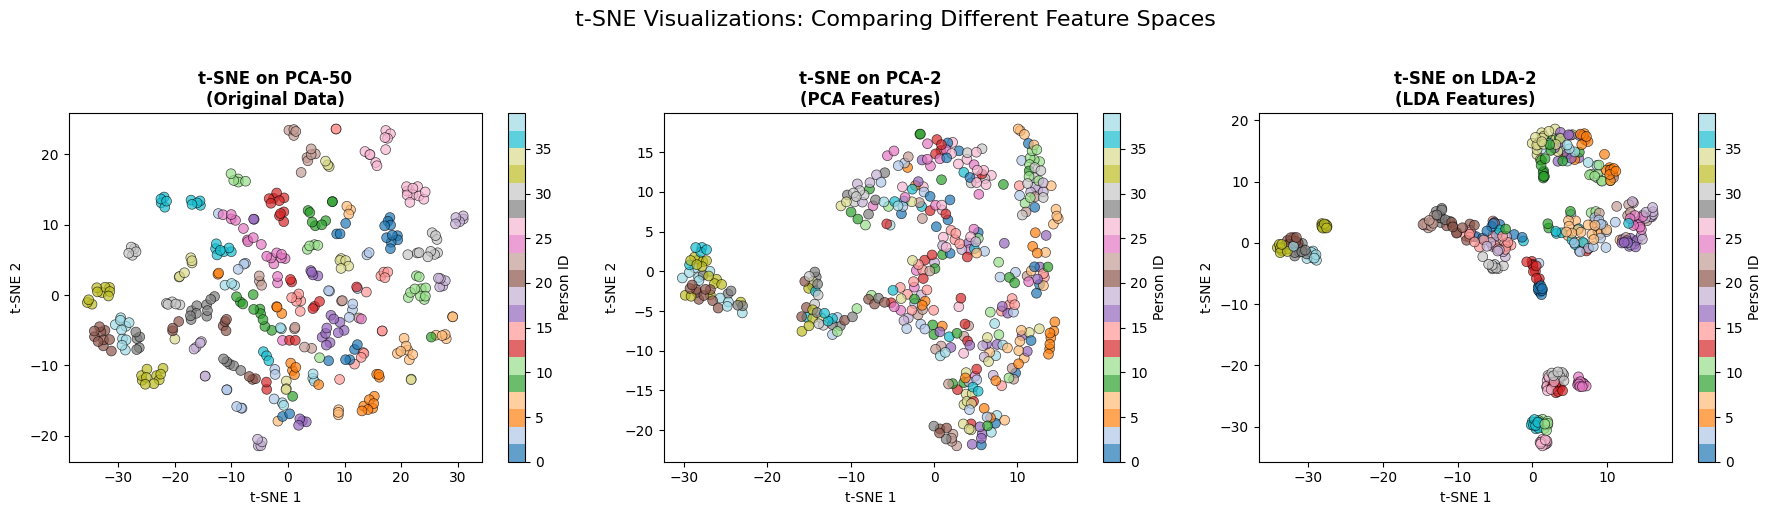


t-SNE reveals non-linear structure in the data.
Notice how class clusters become more distinct when using LDA features.


In [ ]:
# Visualize t-SNE results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# t-SNE on PCA-50
scatter1 = axes[0].scatter(X_tsne_original[:, 0], X_tsne_original[:, 1], c=y, cmap='tab20',
                           alpha=0.7, s=50, edgecolors='black', linewidth=0.5)
axes[0].set_title('t-SNE on PCA-50\n(Original Data)', fontweight='bold')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')
plt.colorbar(scatter1, ax=axes[0], label='Person ID')

# t-SNE on PCA-2
scatter2 = axes[1].scatter(X_tsne_pca[:, 0], X_tsne_pca[:, 1], c=y, cmap='tab20',
                           alpha=0.7, s=50, edgecolors='black', linewidth=0.5)
axes[1].set_title('t-SNE on PCA-2\n(PCA Features)', fontweight='bold')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
plt.colorbar(scatter2, ax=axes[1], label='Person ID')

# t-SNE on LDA-2
scatter3 = axes[2].scatter(X_tsne_lda[:, 0], X_tsne_lda[:, 1], c=y, cmap='tab20',
                           alpha=0.7, s=50, edgecolors='black', linewidth=0.5)
axes[2].set_title('t-SNE on LDA-2\n(LDA Features)', fontweight='bold')
axes[2].set_xlabel('t-SNE 1')
axes[2].set_ylabel('t-SNE 2')
plt.colorbar(scatter3, ax=axes[2], label='Person ID')

plt.suptitle('t-SNE Visualizations: Comparing Different Feature Spaces', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print("\nt-SNE reveals non-linear structure in the data.")
print("Notice how class clusters become more distinct when using LDA features.")

## 6. Performance Comparison

Let's directly compare PCA and LDA performance on the same classification task.

In [ ]:
# Comprehensive comparison
print("=" * 60)
print("CLASSIFICATION PERFORMANCE COMPARISON")
print("=" * 60)

# Test with optimal number of components
results = []

# PCA with different component counts
for n_comp in [20, 50, 100, 150]:
    pca_temp = PCA(n_components=n_comp, whiten=True, random_state=42)
    X_train_pca = pca_temp.fit_transform(X_train)
    X_test_pca = pca_temp.transform(X_test)

    clf = SVC(kernel='rbf', C=10, gamma=0.001, random_state=42)
    clf.fit(X_train_pca, y_train)

    test_acc = clf.score(X_test_pca, y_test)
    variance_explained = pca_temp.explained_variance_ratio_.sum()

    results.append({
        'Method': f'PCA-{n_comp}',
        'Components': n_comp,
        'Test Accuracy': test_acc,
        'Variance Explained': variance_explained
    })
    print(f"PCA ({n_comp:3d} comp): Accuracy = {test_acc:.3f}, Variance = {variance_explained:.2%}")

print("\n" + "-" * 60)

# LDA with different component counts
for n_comp in [10, 20, 30, 39]:
    lda_temp = LDA(n_components=n_comp)
    X_train_lda = lda_temp.fit_transform(X_train, y_train)
    X_test_lda = lda_temp.transform(X_test)

    clf = SVC(kernel='rbf', C=10, gamma=0.001, random_state=42)
    clf.fit(X_train_lda, y_train)

    test_acc = clf.score(X_test_lda, y_test)
    variance_explained = lda_temp.explained_variance_ratio_.sum()

    results.append({
        'Method': f'LDA-{n_comp}',
        'Components': n_comp,
        'Test Accuracy': test_acc,
        'Variance Explained': variance_explained
    })
    print(f"LDA ({n_comp:3d} comp): Accuracy = {test_acc:.3f}, Variance = {variance_explained:.2%}")

print("=" * 60)

CLASSIFICATION PERFORMANCE COMPARISON
PCA ( 20 comp): Accuracy = 0.890, Variance = 76.54%
PCA ( 50 comp): Accuracy = 0.950, Variance = 87.93%
PCA (100 comp): Accuracy = 0.980, Variance = 94.37%
PCA (150 comp): Accuracy = 0.970, Variance = 97.23%

------------------------------------------------------------
LDA ( 10 comp): Accuracy = 0.980, Variance = 68.93%
LDA ( 20 comp): Accuracy = 0.970, Variance = 87.76%
LDA ( 30 comp): Accuracy = 0.970, Variance = 96.24%
LDA ( 39 comp): Accuracy = 0.970, Variance = 100.00%


In [ ]:
# Detailed classification report for best models
print("\n" + "=" * 60)
print("DETAILED CLASSIFICATION REPORTS")
print("=" * 60)

# Best PCA model
pca_best = PCA(n_components=150, whiten=True, random_state=42)
X_train_pca_best = pca_best.fit_transform(X_train)
X_test_pca_best = pca_best.transform(X_test)
clf_pca = SVC(kernel='rbf', C=10, gamma=0.001, random_state=42)
clf_pca.fit(X_train_pca_best, y_train)
y_pred_pca = clf_pca.predict(X_test_pca_best)

print("\nPCA (150 components) + SVM:")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_pca):.3f}")

# Best LDA model
lda_best = LDA(n_components=39)
X_train_lda_best = lda_best.fit_transform(X_train, y_train)
X_test_lda_best = lda_best.transform(X_test)
clf_lda = SVC(kernel='rbf', C=10, gamma=0.001, random_state=42)
clf_lda.fit(X_train_lda_best, y_train)
y_pred_lda = clf_lda.predict(X_test_lda_best)

print("\nLDA (39 components) + SVM:")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_lda):.3f}")


DETAILED CLASSIFICATION REPORTS

PCA (150 components) + SVM:
Test Accuracy: 0.970

LDA (39 components) + SVM:
Test Accuracy: 0.970


## 7. When to Use PCA vs LDA

### Key Differences Summary

| Aspect | PCA | LDA |
|--------|-----|-----|
| **Supervision** | Unsupervised | Supervised |
| **Objective** | Maximize variance | Maximize class separability |
| **Labels Required** | No | Yes |
| **Max Components** | min(n_samples, n_features) | n_classes - 1 |
| **Best For** | Data exploration, visualization, preprocessing | Classification tasks |
| **Assumptions** | Linear relationships | Gaussian distributions, equal covariance |
| **Computation** | Generally faster | Can be slower for large datasets |
| **Overfitting** | Less prone (unsupervised) | More prone if n_samples is small |

## In Lab Tasks

Link to  the ataset :<br>
https://www.kaggle.com/code/bhavesh302/pca-on-wine-dataset

Apply PCA without fixing n_components. <br>

Plot: <br>
1. Explained variance ratio<br>
2. Cumulative explained variance

Determine the minimum number of components required to explain: <br>
1. 90% variance
2. 95% variance

Identify the number of classes in the Wine dataset.<br>
Compute the maximum number of LDA components possible.

Split the dataset into training and testing sets.<br>

Train Logistic Regression on:<br>
PCA-transformed features<br>
LDA-transformed features<br>

Compare both of them using various classification metrics

Train Logistic Regression on:<br>
1. PCA (2D)<br>
2. LDA (2D)

Plot decision boundaries for both cases.